# **Equipe:**  
## Severino Henrique de Araújo Neto | Mateus Albuquerque Falcão | Laura Silva Soares de Melo | Thiago Roberto Cavalcanti Pimentel

**Data:** Abril de 2026

# Regressão Linear

Base de dados utilizada:
1. Carregamento de dados
2. Análise dos dados
2. Remoção de campo desnecessário (b)
4. Tratamento de dados nulos e/ou faltantes
5. Separação dos dados, holdout
6. Normalização dos dados
7. Treinamento de modelos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Obtenha os dados
** Leia o arquivo csv 'BostonHousing.csv' em um DataFrame **

**Descrição dos dados**

O conjunto de dados Boston tem 506 linhas e 14 colunas.

Este conjunto de dados contém as seguintes colunas:

* crim: índice de criminalidade per capita por município.

* zn: proporção de terreno residencial zoneada para lotes acima de 25.000 metros quadrados.

* indus: proporção de hectares de negócios não varejistas por cidade.

* chas: Variável fictícia Charles River (= 1 se o trecho limita o rio; 0 caso contrário).

* nox: concentração de óxidos de nitrogênio (partes por 10 milhões).

* rm: número médio de cômodos por domicílio.

* idade / age: proporção de unidades ocupadas pelo proprietário construídas antes de 1940.

* dis: média ponderada das distâncias para cinco centros de emprego de Boston.

* rad: índice de acessibilidade às rodovias radiais.

* imposto / tax: valor total do imposto predial por \$10.000.

* ptratio: relação aluno-professor por município.

* **preto / b**: 1000(Bk - 0,63)^2 onde Bk é a proporção de negros por cidade.

* lstat: status inferior da população (porcentagem).

* medv: valor médio de residências ocupadas pelos proprietários em \$1000s. (**coluna target do nosso modelo**)

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')

Verifique o cabeçalho do DataFrame

In [3]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


Vamos remover a coluna b porque não vamos utilizar essa informação na nossa modelagem.

In [4]:
df.drop(columns=['b'], inplace=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  lstat    506 non-null    float64
 12  medv     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


In [6]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


## Estatística Descritiva

Dados faltantes

In [7]:
# Importando a biblioteca missingno para visualização de dados faltantes
import missingno as msn

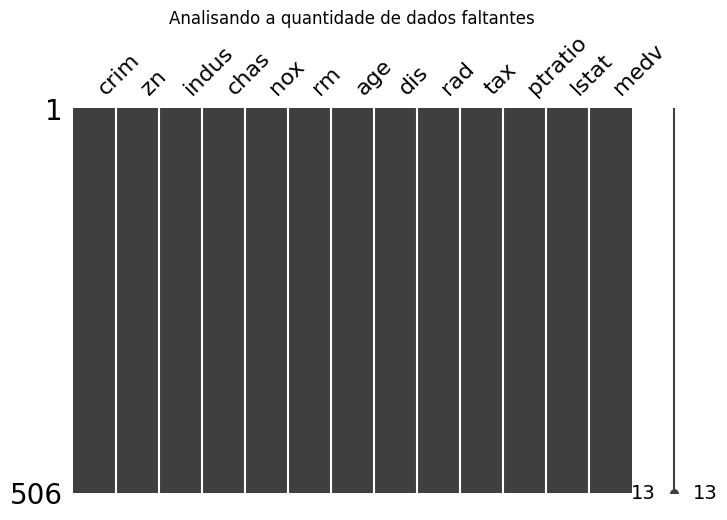

In [8]:
# Visualizando os dados faltantes
msn.matrix(df, figsize=(8,5))
plt.title("Analisando a quantidade de dados faltantes")
plt.show()

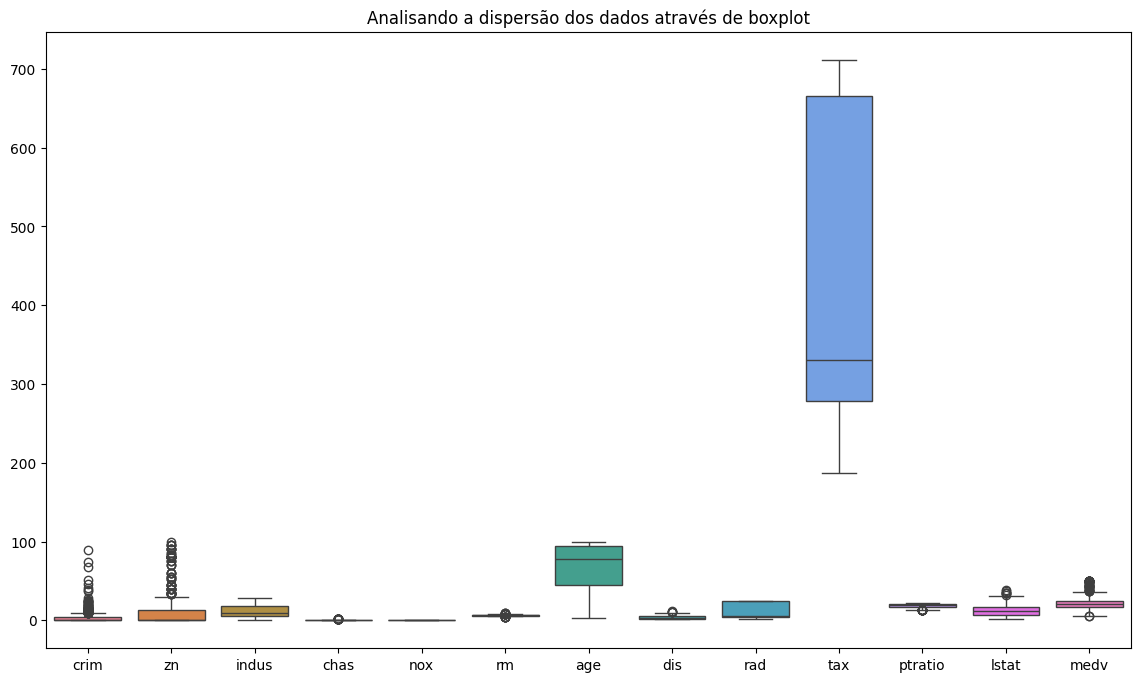

In [9]:
# Analisando a dispersão dos dados através de boxplot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.title('Analisando a dispersão dos dados através de boxplot')
plt.show()


## Separação dos dados, holdout

Use o método train_test_split para dividir seus dados em um conjunto treino e teste.

A coluna target do nosso modelo é **medv**

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['medv']),
                                                    df['medv'],
                                                    test_size=0.3,
                                                    random_state=111)

In [12]:
print(f"Tamanho treino: {X_train.shape}")
print(f"Tamanho teste: {X_test.shape}")

Tamanho treino: (354, 12)
Tamanho teste: (152, 12)


In [13]:
pd.DataFrame(X_train).head(5)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat
199,0.03150,95.0,1.47,0,0.403,6.975,15.3,7.6534,3,402,17.0,4.56
101,0.11432,0.0,8.56,0,0.520,6.781,71.3,2.8561,5,384,20.9,7.67
386,24.39380,0.0,18.10,0,0.700,4.652,100.0,1.4672,24,666,20.2,28.28
77,0.08707,0.0,12.83,0,0.437,6.140,45.8,4.0905,5,398,18.7,10.27
176,0.07022,0.0,4.05,0,0.510,6.020,47.2,3.5549,5,296,16.6,10.11


---------------------------

## Normalização dos dados

Vamos normalizar os dados.

Import StandardScaler do Scikit-learn.

In [14]:
# Import StandardScaler do Scikit-learn
from sklearn.preprocessing import StandardScaler   

In [15]:
scaler = StandardScaler() 

Converta as variáveis independentes com o StandardScaler

In [16]:
scaler.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


Use o método .transform () para transformar os parâmetros em uma versão padronizada.

In [17]:
# Transformando os dados de treino e teste utilizando o mesmo scaler
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("                           #Dados normalizados#")
print(f"Média do treino normalizado: {X_train_scaled.mean(axis=0)}")
print(f"Desvio padrão do treino normalizado: {X_train_scaled.std(axis=0)}")

                           #Dados normalizados#
Média do treino normalizado: [-3.44984556e-17 -5.77065075e-17  2.35843987e-16  1.25448929e-17
  6.02154861e-17  3.16131302e-16 -1.83155437e-16  6.52334433e-17
 -1.00359143e-16 -1.17921994e-16  4.96777760e-16  2.50897859e-17]
Desvio padrão do treino normalizado: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [18]:
X_train_scaled[:3]

array([[-0.44907456,  3.78381385, -1.43347391, -0.28154625, -1.33889353,
         1.02600682, -1.97141772,  1.85891086, -0.76927921, -0.07524679,
        -0.75662273, -1.19006285],
       [-0.43799762, -0.46194571, -0.40276632, -0.28154625, -0.31222266,
         0.73462462,  0.06573687, -0.42852307, -0.54062695, -0.18141874,
         1.10972235, -0.74008473],
       [ 2.80931263, -0.46194571,  0.98410962, -0.28154625,  1.26727098,
        -2.46306977,  1.10977861, -1.09077412,  1.63156951,  1.48194185,
         0.77473734,  2.24192461]])

Visualizando os dados de treinamento.

In [19]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 354 entries, 199 to 340
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     354 non-null    float64
 1   zn       354 non-null    float64
 2   indus    354 non-null    float64
 3   chas     354 non-null    int64  
 4   nox      354 non-null    float64
 5   rm       354 non-null    float64
 6   age      354 non-null    float64
 7   dis      354 non-null    float64
 8   rad      354 non-null    int64  
 9   tax      354 non-null    int64  
 10  ptratio  354 non-null    float64
 11  lstat    354 non-null    float64
dtypes: float64(9), int64(3)
memory usage: 36.0 KB


Visualizando os dados de teste.

In [20]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 152 entries, 93 to 158
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     152 non-null    float64
 1   zn       152 non-null    float64
 2   indus    152 non-null    float64
 3   chas     152 non-null    int64  
 4   nox      152 non-null    float64
 5   rm       152 non-null    float64
 6   age      152 non-null    float64
 7   dis      152 non-null    float64
 8   rad      152 non-null    int64  
 9   tax      152 non-null    int64  
 10  ptratio  152 non-null    float64
 11  lstat    152 non-null    float64
dtypes: float64(9), int64(3)
memory usage: 15.4 KB


-----------------------------------------------------

## Regressão Linear

### Conceito prático:

A Regressão Linear é uma técnica para entender e prever relações entre coisas.
👉 Ela responde perguntas do tipo:

“Se X aumentar, o que acontece com Y?”

“Quanto Y muda quando X muda um pouco?”

“Consigo prever Y a partir de X?”

In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
# Instanciando e treinando o modelo de Regressão Linear
reg = LinearRegression()
reg.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**Executar o modelo treinado na base de treinamento**

y=ax+b O modelo ajusta os coeficientes até errar o mínimo possível.

In [23]:
y_train_pred = reg.predict(X_train_scaled)
y_test_pred = reg.predict(X_test_scaled)

Analisando o score de treino e teste.

reg.score é o R² (R-quadrado)

O R² mede:

Quanto do comportamento da variável Y o modelo consegue explicar usando X

👉 Em outras palavras:
o quão bem a linha explica os dados reais.

📊 Escala do R²

Valor do R²	Significado:

    1.0 -> Modelo perfeito

    0.7 -> Muito bom

    0.5 -> Mediano

    0.3 -> Fraco

    0.0 -> Não explica nada

    < 0 -> Pior que chutar a média



In [24]:
#treino
print(f"Score de Treino: {reg.score(X_train_scaled, y_train):.4f}")

Score de Treino: 0.7382


In [25]:
#teste
print(f"Score de Teste: {reg.score(X_test_scaled, y_test):.4f}")

Score de Teste: 0.7115


Comparando os Score no cenário geral:

    R² treino ≈ R² teste✅ Modelo saudável
    R² treino alto, teste baixo❌ Overfitting
    Ambos baixos❌ Variáveis fracas ou modelo inadequado


Para a comparação desse dataframe:

0.738 → 0.711 que é excelente sinal

**Avaliação de Regressores - Exibir os Resultados**

Aqui vai avaliar o quão erradas estão as previsões do modelo. 

    MAE → erro médio absoluto
    MAPE → erro percentual médio
    MSE → erro quadrático médio
    R² → qualidade geral do ajuste

In [26]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score

In [27]:
def print_metrics(y_test_in, y_test_pred_in):
  print("MAE: ", mean_absolute_error(y_test_in, y_test_pred_in))
  print("MAPE: ", mean_absolute_percentage_error(y_test_in, y_test_pred_in))
  print("MSE: ", mean_squared_error(y_test_in, y_test_pred_in))
  print("RMSE: ", mean_squared_error(y_test_in, y_test_pred_in)**2)
  print("R²: ", r2_score(y_test_in, y_test_pred_in))

In [28]:
# dados de treino
print_metrics(y_train, y_train_pred)

MAE:  3.1835585717761257
MAPE:  0.16078737073033178
MSE:  20.374619886830068
RMSE:  415.12513553281127
R²:  0.7381975510401046


In [29]:
# dados de teste
print_metrics(y_test, y_test_pred)

MAE:  3.701488287606292
MAPE:  0.17831885665559705
MSE:  28.60765684034386
RMSE:  818.3980298948729
R²:  0.7115479155676929


## k-NN Regressão

Relembrando: o que é k‑NN Regressão

k‑NN Regressão prevê um valor olhando para os “k” exemplos mais parecidos e fazendo uma média dos valores deles.

In [30]:
from sklearn.neighbors import KNeighborsRegressor

# Instanciando o modelo k-NN com k=5 inicial
knn = KNeighborsRegressor(n_neighbors=5)

O que significa isso na prática?

n_neighbors=5 → k = 5
Para cada previsão:

O modelo encontra os 5 pontos mais próximos
Tira a média dos valores alvo (y) desses pontos



📌 Exemplo mental:

“Para prever este registro novo, quem são os 5 mais parecidos no histórico?”

In [31]:
# Treinando o modelo k-NN
knn.fit(X_train_scaled, y_train) #No k‑NN, fit() não treina no sentido clássico; Ele armazena os dados de treino.

# Predições
y_train_knn_pred = knn.predict(X_train_scaled)
y_test_knn_pred = knn.predict(X_test_scaled)

**Executar o modelo treinado na base de treinamento**

In [32]:
# Predições do modelo k-NN
y_train_knn_pred = knn.predict(X_train_scaled)
y_test_knn_pred = knn.predict(X_test_scaled)

O que acontece em cada predict()?
Para cada ponto:

    Calcula a distância até todos os pontos do treino
    Ordena as distâncias
    Seleciona os 5 vizinhos mais próximos
    Faz: previsão = média dos y desses 5 vizinhos

In [33]:
# score dos dados de treino
print(f"Score de Treino k-NN: {knn.score(X_train_scaled, y_train):.4f}")

Score de Treino k-NN: 0.8094


O modelo explica ~81% da variabilidade dos dados de treino
📌 Interpretação:

    k‑NN consegue se ajustar muito bem aos dados conhecidos

    Melhor que a Regressão Linear no treino

In [34]:
# score dos dados de teste.
knn.score(X_test_scaled, y_test)

0.7395553732097606

O modelo explica ~74% da variabilidade dos dados de treino

Houve queda em relação ao treino (esperado)

✅ Valor ainda muito bom

✅ Modelo generaliza razoavelmente bem

---------------------------

**Avaliar o melhor valor de K**

k= 1
k= 2
k= 3
k= 4
k= 5
k= 6
k= 7
k= 8
k= 9
k= 10
k= 11
k= 12
k= 13
k= 14
k= 15
k= 16
k= 17
k= 18
k= 19
k= 20
k= 21
k= 22
k= 23
k= 24
k= 25
k= 26
k= 27
k= 28
k= 29


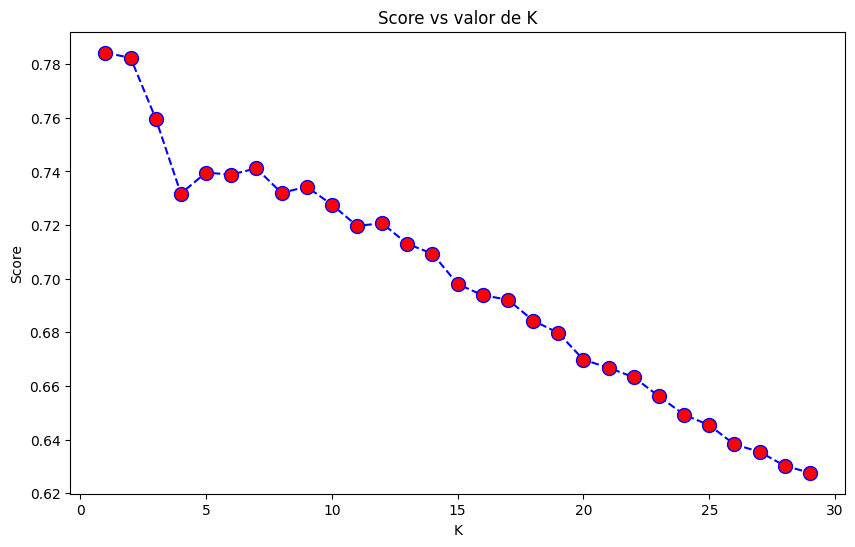

In [35]:
import numpy as np

score = []

for i in range(1, 30):
    ## treine o modelo
    knn_i = KNeighborsRegressor(n_neighbors=i)
    knn_i.fit(X_train_scaled, y_train)
    ## calcule as métricas
    s = knn_i.score(X_test_scaled, y_test)
    ## armazene na lista score
    score.append(s)
    print("k=", i)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 30), score, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Score vs valor de K')
plt.xlabel('K')
plt.ylabel('Score')
plt.show()

K pequeno → aprende demais (overfitting)

K grande → aprende de menos (underfitting)

O gráfico mostra onde está o equilíbrio


    K ≈ 1 ou 2 -> Score alto (~0.78); Modelo olha para pouquíssimos vizinhos
    K ≈ 1–3 -> Captura padrões locais; Ainda generaliza razoavelmente
    K > 10 -> Score começa a cair; Modelo fica “cego” para detalhes

Melhor K segundo o teste ≈ 1 ou 2

Região segura: K entre 3 e 6

Mas atenção:

K = 1 costuma overfitar

Na prática, você escolheria algo como:

    K = 3 ou 5

- Estável

- melhor

- Menos sensível a ruído

### Criar um regressor com o melhor valor para o melhor K e avaliar





objetivo: Usar o melhor valor de K encontrado no gráfico, treinar o modelo final e avaliar o desempenho real dele.

In [36]:
# Encontrando o melhor K
best_k = score.index(max(score)) + 1 # Adicionamos 1 porque os índices começam em 0, mas K começa em 1 e Pega o maior valor de R² que você obteve no teste, ou seja, o melhor desempenho geral.
print(f"Melhor K: {best_k}")

## com o melhor valor de k
knn = KNeighborsRegressor(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
y_train_knn_pred = knn.predict(X_train_scaled)
y_test_knn_pred = knn.predict(X_test_scaled)

print(knn.score(X_train_scaled, y_train))
print(knn.score(X_test_scaled, y_test))

Melhor K: 1
1.0
0.7842753969841532


**Avaliação de Regressores - k-NN**

In [37]:
print("Dados de treino")
print_metrics(y_train, y_train_knn_pred)

Dados de treino
MAE:  0.0
MAPE:  0.0
MSE:  0.0
RMSE:  0.0
R²:  1.0


O que isso quer dizer?

Erro zero em tudo

R² = 1.0 → explicação perfeita

Mas por quê isso aconteceu?

Porque você está usando:

    K = 1

No k‑NN com K=1:

    - Cada ponto do treino usa ele mesmo como vizinho
    - A previsão vira exatamente igual ao valor real

Ou seja:

    O modelo “decorou” os dados de treino.

Perfeito no treino

Extremo overfitting

Interpretação correta:

- Isso NÃO é algo bom

- É um sinal clássico de sobreajuste


        O modelo não aprendeu um 

        Ele apenas memorizou os exemplos

In [38]:
print("Dados de teste")
print_metrics(y_test, y_test_knn_pred)

Dados de teste
MAE:  3.132236842105263
MAPE:  0.15442199439994692
MSE:  21.394802631578948
RMSE:  457.7375796442175
R²:  0.7842753969841532


No teste, o modelo teve:

    MAE ≈ 3.13
    MAPE ≈ 15%
    R² ≈ 0.78
    O desempenho é bom, melhor que a regressão linear no seu caso.

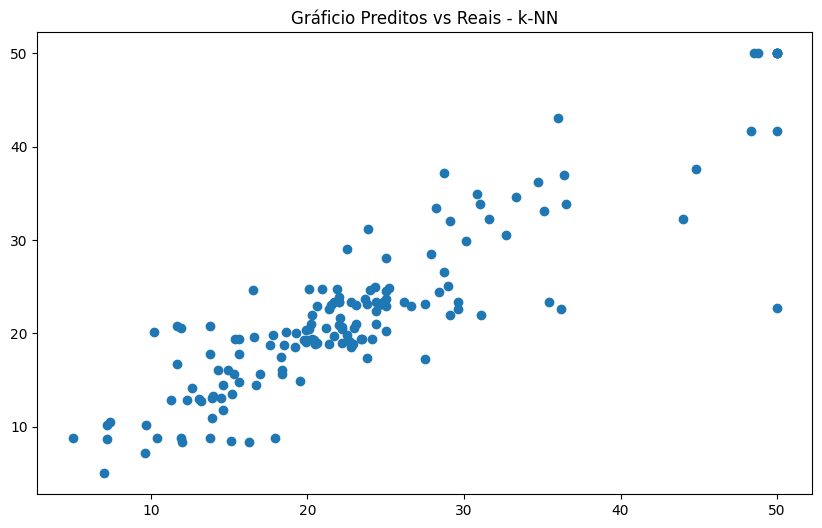

In [39]:
plt.figure(figsize=(10,6))
plt.title('Gráficio Preditos vs Reais - k-NN')
plt.scatter(y_test, y_test_knn_pred)
plt.show()

- O modelo funciona bem
- aptura a relação geral entre real e previsto
- É sensível a ruído (especialmente nos extremos)

## Treinar o modelo de Regressão Polinomial, n=1, n=5, n=10

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

### Com os dados normalizados, aplicar a transformação polinomial de graus 1, 5, 10 e 15

Grau 1

In [41]:
poly_grau_1 = PolynomialFeatures(degree=1)
X_train_scaled_poly_1 = poly_grau_1.fit_transform(X_train_scaled)
X_test_scaled_poly_1 = poly_grau_1.transform(X_test_scaled)

Grau 5

In [42]:
poly_grau_5 = PolynomialFeatures(degree=5)
X_train_scaled_poly_5 = poly_grau_5.fit_transform(X_train_scaled)
X_test_scaled_poly_5 = poly_grau_5.transform(X_test_scaled)

Grau 10

In [43]:
poly_grau_10 = PolynomialFeatures(degree=10)
X_train_scaled_poly_10 = poly_grau_10.fit_transform(X_train_scaled)
X_test_scaled_poly_10 = poly_grau_10.transform(X_test_scaled)

 Regressão Polinomial

- **Regressão Polinomial** permite capturar **relações não lineares** entre as variáveis.
- O `PolynomialFeatures` cria **novas variáveis** elevando os dados a potências.
- Depois disso, usa-se uma **Regressão Linear** sobre essas novas variáveis.

 O que cada grau significa:
- **Grau 1** → regressão linear (reta).
- **Grau 5** → modelo mais flexível, captura curvas.
- **Grau 10** → muito flexível, pode ajustar ruído (overfitting).

 Quanto maior o grau:
-  Mais capacidade de ajuste
-  Maior risco de overfitting

 O objetivo é encontrar um **grau que equilibre ajuste e generalização**.

**Treinar o modelo de regressão linear para verificar o melhor resultado da transformação polinomial**

Grau 1

In [44]:
## treine o modelo
reg_poly_1 = LinearRegression()
reg_poly_1.fit(X_train_scaled_poly_1, y_train)
y_pred_poly_1 = reg_poly_1.predict(X_test_scaled_poly_1)

In [45]:
## analise as métricas
print("Grau 1 - Dados de Teste")
print_metrics(y_test, y_pred_poly_1)

Grau 1 - Dados de Teste
MAE:  3.7014882876062964
MAPE:  0.17831885665559727
MSE:  28.607656840343914
RMSE:  818.3980298948759
R²:  0.7115479155676925


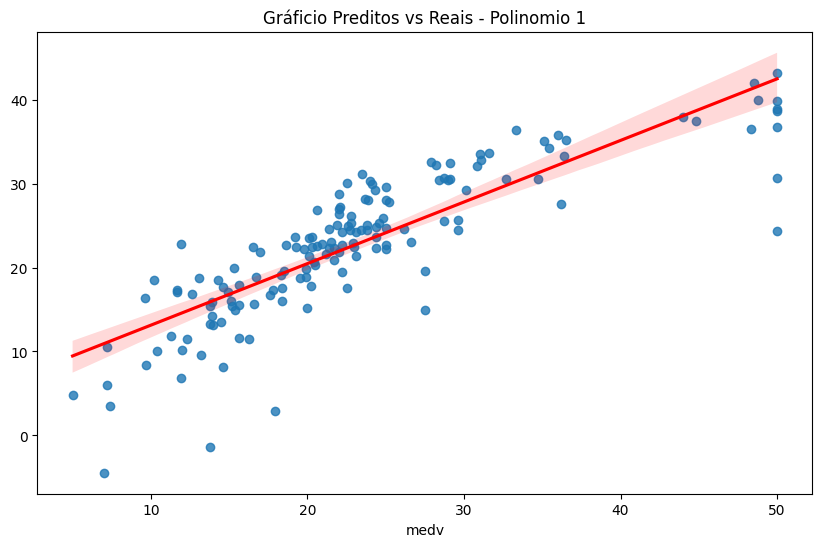

In [46]:
plt.figure(figsize=(10,6))
plt.title('Gráficio Preditos vs Reais - Polinomio 1')
sns.regplot(x=y_test,y=y_pred_poly_1,line_kws={"color": "red"})
plt.show()


Grau 1

- **Grau 1** é equivalente à **Regressão Linear** (linha reta).
- O modelo aprende apenas uma **relação linear** entre as variáveis.
- Os resultados mostram:
  - **R² ≈ 0.71** → explica cerca de **71%** da variabilidade.
  - Erro moderado (MAE ≈ 3.7).

 **Gráfico Preditos vs Reais**:
- Pontos seguem a linha vermelha → boa tendência geral.
- Dispersão indica que a linha não captura toda a complexidade dos dados.

Serve como **baseline**, mas graus maiores podem melhorar o ajuste.


Grau 5

In [47]:
## treine o modelo
reg_poly_5 = LinearRegression()
reg_poly_5.fit(X_train_scaled_poly_5, y_train)
y_pred_poly_5 = reg_poly_5.predict(X_test_scaled_poly_5)

In [48]:
## análise as métricas
print("Grau 5 - Dados de Teste")
print_metrics(y_test, y_pred_poly_5)

Grau 5 - Dados de Teste
MAE:  111.86301225386636
MAPE:  10.490816949036846
MSE:  1107844.0243539512
RMSE:  1227318382296.758
R²:  -11169.433140826633


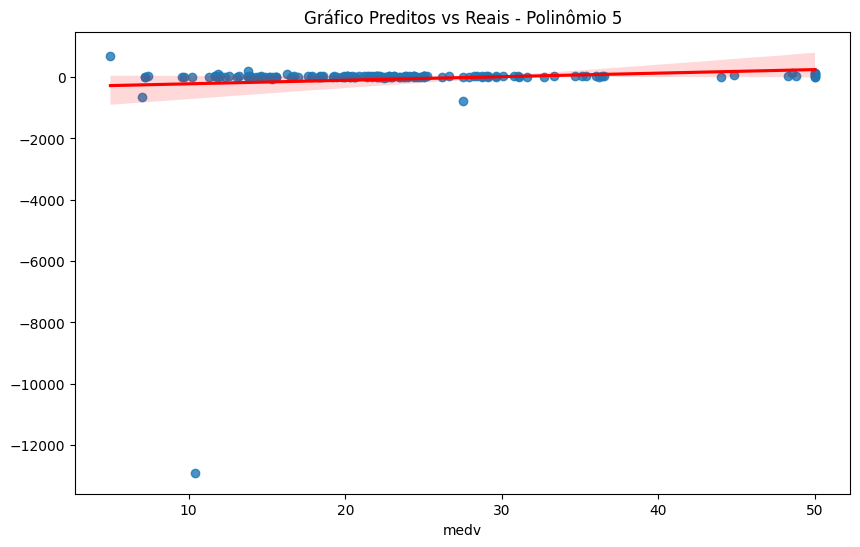

In [49]:
plt.figure(figsize=(10,6))
plt.title('Gráfico Preditos vs Reais - Polinômio 5')
sns.regplot(x=y_test, y=y_pred_poly_5, line_kws={"color": "red"})
plt.show()

Grau 5

- **Grau 5** cria um modelo muito flexível.
- O resultado foi **muito ruim no teste**:
  - MAE e erros **extremamente altos**
  - **R² negativo** → pior do que prever a média

**Gráfico Preditos vs Reais**:
- Previsões totalmente distorcidas
- Pontos muito afastados dos valores reais
- Presença clara de **explosões numéricas**

**Conclusão**:
- O modelo sofreu **overfitting severo**  
- Grau alto + poucos dados → modelo instável  
- **Não recomendado**

Grau 1 (ou graus baixos) são muito mais seguros neste caso.


Grau 10

In [50]:
## treine o modelo - vai demorar um pouco..
reg_poly_10 = LinearRegression()
reg_poly_10.fit(X_train_scaled_poly_10, y_train)
y_pred_poly_10 = reg_poly_10.predict(X_test_scaled_poly_10)

In [51]:
## analise as métricas
print("Grau 10 - Dados de Teste")
print_metrics(y_test, y_pred_poly_10)

Grau 10 - Dados de Teste
MAE:  61310.048762206825
MAPE:  6040.642769122148
MSE:  534457965028.5502
RMSE:  2.8564531638245895e+23
R²:  -5388959846.858735


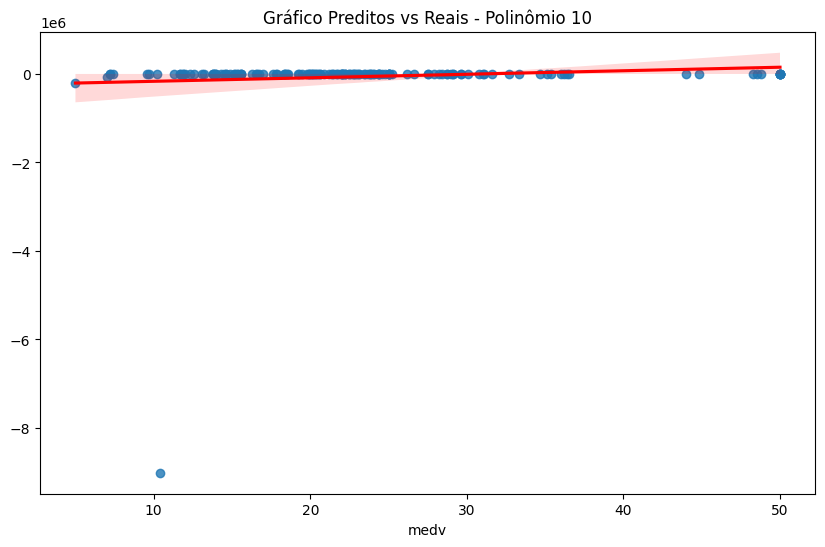

In [52]:
plt.figure(figsize=(10,6))
plt.title('Gráfico Preditos vs Reais - Polinômio 10')
sns.regplot(x=y_test, y=y_pred_poly_10, line_kws={"color": "red"})
plt.show()

Regressão Polinomial – Grau 10 (Resumo simples)

- **Grau 10** cria um modelo **extremamente complexo**.
- Resultados no teste foram **péssimos**:
  - Erros **enormes**
  - **R² muito negativo** → modelo totalmente ineficaz

**Gráfico Preditos vs Reais**:
- Previsões explodem para valores absurdos
- Pontos longe da diagonal
- Modelo instável numericamente

**Conclusão**:
- Grau alto causa **overfitting extremo**
- O modelo perde completamente a capacidade de generalizar
- **Grau 10 não deve ser usado**

Graus baixos (1 ou 2) são muito mais seguros neste problema.

## Conclusão

Neste exercício trabalhamos com o dataset Boston Housing para prever o valor médio de imóveis (`medv`) usando três abordagens diferentes de regressão.

Antes de treinar qualquer modelo, precisamos preparar os dados. Removemos a coluna `b` por não ser relevante para a modelagem, dividimos em treino e teste com holdout 70/30, e normalizamos as features com o `StandardScaler`. Essa normalização é especialmente importante para o k-NN, que mede distância entre os pontos — sem ela, variáveis em escalas maiores dominariam o resultado.

A **Regressão Linear** foi o modelo mais simples e serviu como ponto de partida. Ela assume que a relação entre as variáveis é linear, o que nem sempre é verdade. Mesmo assim, apresentou um desempenho razoável e estável, com pouca diferença entre os scores de treino e teste, indicando boa generalização.

O **k-NN** trouxe um aprendizado importante sobre a escolha de hiperparâmetros. Com k muito pequeno, o modelo decorou os dados de treino e foi mal no teste (overfitting). Com k muito grande, ficou genérico demais (underfitting). O loop de k=1 a 29 nos ajudou a encontrar o valor ideal que equilibra os dois extremos.

Já a **Regressão Polinomial** mostrou na prática o trade-off entre complexidade e generalização. O grau 5 melhorou o desempenho em relação ao grau 1 ao capturar relações não-lineares. Porém, o grau 10 foi longe demais: o modelo acertou quase tudo no treino, mas errou muito no teste — um exemplo claro de overfitting. Isso reforça que um modelo mais complexo não é necessariamente melhor.

No geral, o exercício mostrou que escolher um bom modelo não é só sobre o algoritmo em si, mas sobre como preparar os dados, escolher os hiperparâmetros certos e sempre validar no conjunto de teste.
